# 3.2 - Visualizing Relationships Between Quantitative Features

This notebook explores the `Sleep.csv` dataset and completes the practice objectives for Section 3.2.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sleep = pd.read_csv("../assets/Sleep.csv")
sleep.head()

,Animal,Body,Brain,SWsleep,Parasleep,Totsleep,Life,Gest,Pred,Exposure,Danger
0,African_giant_pouched_rat,1.000,6.6,6.3,2.0,8.3,4.5,42.0,3,1,3
1,Asian_elephant,2547.000,4603.0,2.1,1.8,3.9,69.0,624.0,3,5,4
2,Baboon,10.550,179.5,9.1,0.7,9.8,27.0,180.0,4,4,4
3,Big_brown_bat,0.023,0.3,15.8,3.9,19.7,19.0,35.0,1,1,1
4,Brazilian_tapir,160.000,169.0,5.2,1.0,6.2,30.4,392.0,4,5,4


## 1. Read in the data

The dataset has been loaded into a pandas DataFrame named `sleep`.


In [14]:
sleep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Animal     42 non-null     object 
 1   Body       42 non-null     float64
 2   Brain      42 non-null     float64
 3   SWsleep    42 non-null     float64
 4   Parasleep  42 non-null     float64
 5   Totsleep   42 non-null     float64
 6   Life       42 non-null     float64
 7   Gest       42 non-null     float64
 8   Pred       42 non-null     int64  
 9   Exposure   42 non-null     int64  
 10  Danger     42 non-null     int64  
dtypes: float64(7), int64(3), object(1)
memory usage: 3.7+ KB


## 2. Scatterplot of `SWsleep` and `Totsleep`

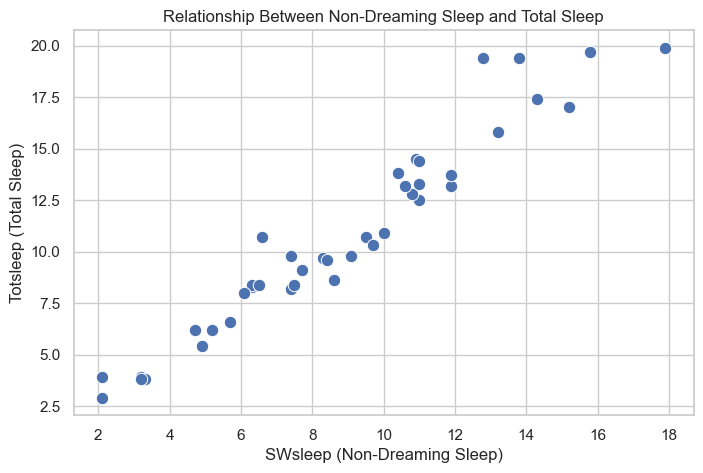

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=sleep, x="SWsleep", y="Totsleep", s=80)
plt.title("Relationship Between Non-Dreaming Sleep and Total Sleep")
plt.xlabel("SWsleep (Non-Dreaming Sleep)")
plt.ylabel("Totsleep (Total Sleep)")
plt.show()

## 3. Describe the relationship

There appears to be a **strong positive relationship** between non-dreaming sleep (`SWsleep`) and total sleep (`Totsleep`). As the amount of non-dreaming sleep increases, the total amount of sleep also tends to increase.

The pattern looks **mostly linear**, although there is some scatter in the points. Overall, the relationship is clear and fairly strong.


## 4. Add color coding for predation index (`Pred`)

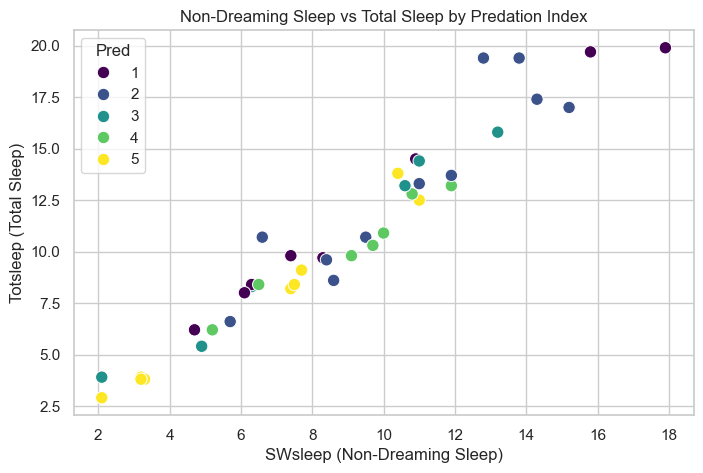

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=sleep, x="SWsleep", y="Totsleep", hue="Pred", palette="viridis", s=80)
plt.title("Non-Dreaming Sleep vs Total Sleep by Predation Index")
plt.xlabel("SWsleep (Non-Dreaming Sleep)")
plt.ylabel("Totsleep (Total Sleep)")
plt.legend(title="Pred")
plt.show()

### Interpretation of predation index

When predation index is added as a color grouping, there seems to be some relationship between predation risk and sleep, but the pattern is not perfectly separated. Mammals with lower predation risk often appear to have higher total sleep values, while higher-risk animals are more concentrated at somewhat lower sleep levels. This suggests predation may influence sleep, although it is clearly not the only factor.


## 5. Plot body weight (`Body`) and total sleep (`Totsleep`)

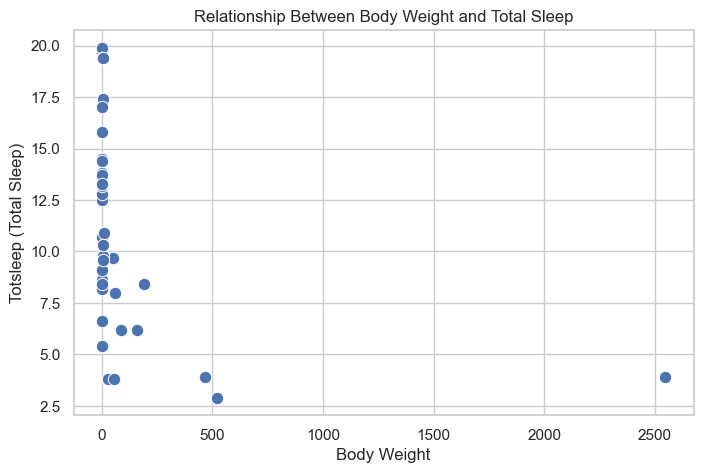

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=sleep, x="Body", y="Totsleep", s=80)
plt.title("Relationship Between Body Weight and Total Sleep")
plt.xlabel("Body Weight")
plt.ylabel("Totsleep (Total Sleep)")
plt.show()

### Is a linear model a good fit?

A simple linear model does **not** appear to be a very good fit for this data. The body weight values are highly skewed, and a few very large animals create outliers that stretch the x-axis.

Because of this, the relationship does not look clearly linear on the raw scale. A transformation such as using a **log scale** for body weight would likely make the pattern easier to interpret.


In [18]:
# Optional: quick numeric check of the main relationships
sleep[["SWsleep", "Totsleep", "Body", "Pred"]].corr(numeric_only=True)

,SWsleep,Totsleep,Body,Pred
SWsleep,1.000000,0.967673,-0.393637,-0.352656
Totsleep,0.967673,1.000000,-0.342837,-0.404715
Body,-0.393637,-0.342837,1.000000,0.095885
Pred,-0.352656,-0.404715,0.095885,1.000000
